# Supplementary Figure 12.3: NucleusNet autoencoder training loss.

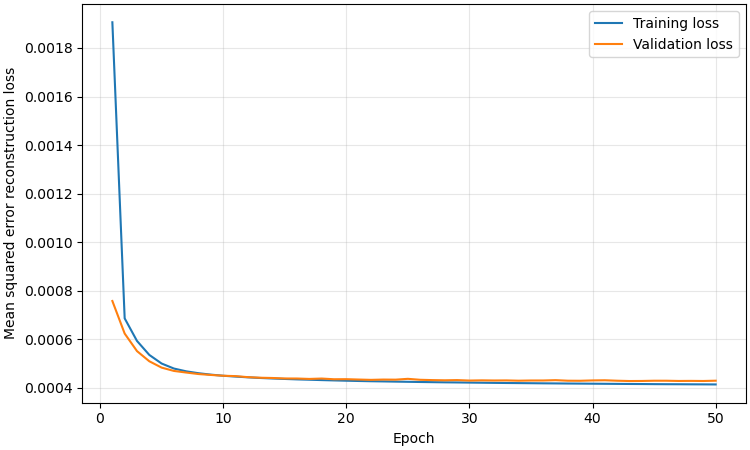

In [1]:
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Optional interactive backend
try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "widget")
except Exception:
    pass

# ─────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────
LOG_DIR = Path("..") / "data" / "nucleus-ae"
LOG_FILE = LOG_DIR / "training_log.csv"

# ─────────────────────────────────────────────────────────
# Load training log
# ─────────────────────────────────────────────────────────
def load_training_log(csv_path):
    """Load training log CSV and extract epoch, loss, and validation loss."""
    if not csv_path.exists():
        raise FileNotFoundError(f"Training log not found: {csv_path}")
    
    with open(csv_path, "r", newline="", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f)
        rows = list(reader)
        fieldnames = reader.fieldnames or []
    
    if not rows:
        raise ValueError(f"CSV is empty: {csv_path}")
    
    def get_column(possible_names):
        """Try multiple column names, return first match as float array or None."""
        names = possible_names if isinstance(possible_names, list) else [possible_names]
        for name in names:
            if name in fieldnames:
                vals = []
                for row in rows:
                    try:
                        vals.append(float(row.get(name, "")))
                    except (ValueError, TypeError):
                        vals.append(np.nan)
                return np.array(vals, dtype=float)
        return None
    
    # Extract columns
    epoch_col = get_column(["epoch"])
    loss = get_column(["loss", "mse", "train_loss", "training_loss"])
    val_loss = get_column(["val_loss", "val_mse", "validation_loss"])
    
    # Create epoch array (1-indexed if not present or 0-indexed in file)
    if epoch_col is not None:
        epochs = epoch_col.astype(int)
        if epochs.min() == 0:
            epochs = epochs + 1
    else:
        epochs = np.arange(1, len(rows) + 1)
    
    return epochs, loss, val_loss

# ─────────────────────────────────────────────────────────
# Load and plot
# ─────────────────────────────────────────────────────────

#| label: sfig12c_data

epochs, loss, val_loss = load_training_log(LOG_FILE)

fig, ax = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)

if loss is not None:
    ax.plot(epochs, loss, label="Training loss")
if val_loss is not None:
    ax.plot(epochs, val_loss, label="Validation loss")

if loss is None and val_loss is None:
    raise ValueError(
        "No loss columns found. Expected one of: "
        "loss, mse, train_loss, training_loss, val_loss, val_mse, validation_loss"
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean squared error reconstruction loss")
ax.grid(True, alpha=0.3)
ax.legend()

fig.canvas.toolbar_visible = True
fig.canvas.header_visible = False
fig.canvas.footer_visible = False

plt.show()